<a href="https://colab.research.google.com/github/josetingeo/cucumber_leaf_disease_detiction/blob/main/Copy_of_Leaf_Disease_Detection_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
project_path = "/content/drive/MyDrive/mini project"

In [4]:
dataset_path = os.path.join(
    project_path,
    "Dataset",
    "cucumber_Leaf_Disease"
)

print(dataset_path)

/content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease


In [5]:
if os.path.exists(dataset_path):
    print("✅ Dataset Found")
else:
    print("❌ Dataset Not Found")

✅ Dataset Found


In [6]:
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

In [7]:
print("Disease Classes:\n")

classes = os.listdir(train_path)

for disease in classes:
    print(disease)

Disease Classes:

Downy_mildew
Healthy_leaves
Powdery_mildew
Model


In [8]:
print("Total Classes :", len(classes))

Total Classes : 4


In [9]:
disease_classes = os.listdir(train_path)

print(disease_classes)

['Downy_mildew', 'Healthy_leaves', 'Powdery_mildew', 'Model']


In [10]:
print("Training Dataset\n")

for disease in disease_classes:

    disease_folder = os.path.join(train_path, disease)

    image_count = len(os.listdir(disease_folder))

    print(f"{disease} : {image_count} Images")

Training Dataset

Downy_mildew : 1284 Images
Healthy_leaves : 1229 Images
Powdery_mildew : 1190 Images
Model : 0 Images


In [11]:
train_path = os.path.join(dataset_path, "train")
disease_classes = os.listdir(train_path)

IndexError: list index out of range

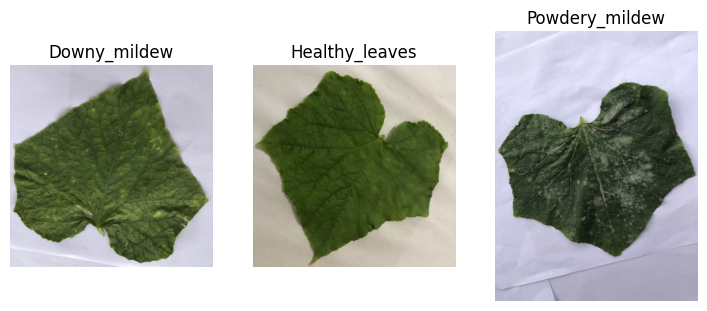

In [13]:
plt.figure(figsize=(12,4))

for i, disease in enumerate(disease_classes):

    disease_folder = os.path.join(train_path, disease)

    image_name = os.listdir(disease_folder)[0]

    image_path = os.path.join(disease_folder, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(disease_classes), i+1)
    plt.imshow(image)
    plt.title(disease)
    plt.axis("off")

plt.show()

In [14]:
healthy_path = os.path.join(train_path, "Healthy_leaves")

image_name = os.listdir(healthy_path)[0]

image_path = os.path.join(healthy_path, image_name)

print(image_path)

/content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train/Healthy_leaves/IMG_2500.JPG


In [15]:
leaf_image = cv2.imread(image_path)

print("Image Loaded Successfully")

Image Loaded Successfully


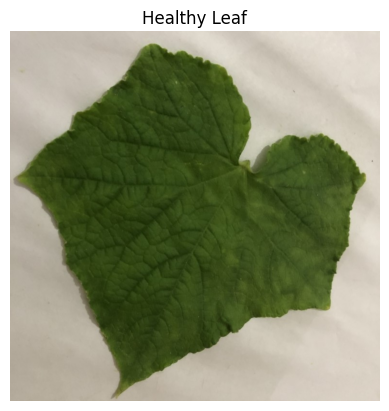

In [16]:
leaf_rgb = cv2.cvtColor(leaf_image, cv2.COLOR_BGR2RGB)

plt.imshow(leaf_rgb)
plt.axis("off")
plt.title("Healthy Leaf")
plt.show()

In [17]:
print("Height :", leaf_image.shape[0])
print("Width  :", leaf_image.shape[1])
print("Channels :", leaf_image.shape[2])

Height : 768
Width  : 768
Channels : 3


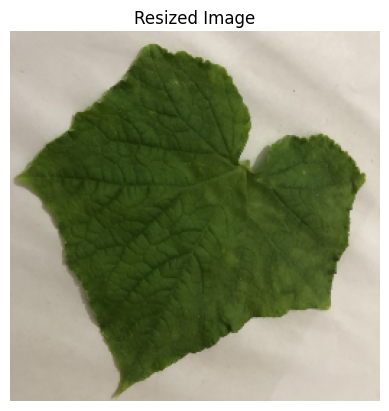

In [18]:
leaf_resize = cv2.resize(leaf_rgb, (256, 256))

plt.imshow(leaf_resize)
plt.title("Resized Image")
plt.axis("off")
plt.show()

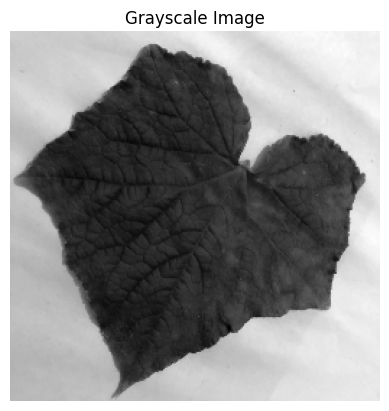

In [19]:
leaf_gray = cv2.cvtColor(leaf_resize, cv2.COLOR_RGB2GRAY)

plt.imshow(leaf_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

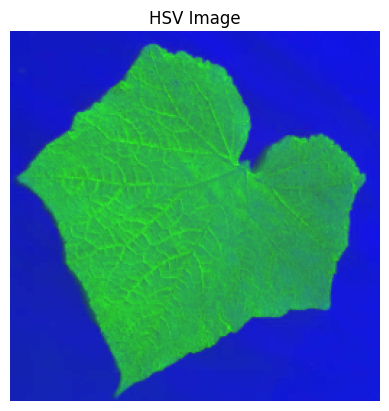

In [20]:
leaf_hsv = cv2.cvtColor(leaf_resize, cv2.COLOR_RGB2HSV)

plt.imshow(leaf_hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

In [21]:
print("RGB Shape :", leaf_resize.shape)
print("Gray Shape:", leaf_gray.shape)
print("HSV Shape :", leaf_hsv.shape)

RGB Shape : (256, 256, 3)
Gray Shape: (256, 256)
HSV Shape : (256, 256, 3)


In [22]:
# HSV range for yellow/brown disease regions
lower = np.array([10, 40, 40])
upper = np.array([40, 255, 255])

disease_mask = cv2.inRange(leaf_hsv, lower, upper)

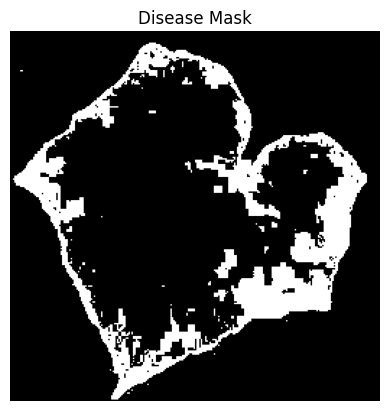

In [23]:
plt.imshow(disease_mask, cmap="gray")
plt.title("Disease Mask")
plt.axis("off")
plt.show()

In [24]:
lower = np.array([10, 40, 40])
upper = np.array([40, 255, 255])

In [25]:
contours, _ = cv2.findContours(
    disease_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contours Found :", len(contours))

Contours Found : 8


In [26]:
result = leaf_resize.copy()

if contours:

    largest = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(largest)

    cv2.rectangle(result, (x, y), (x+w, y+h), (0,255,0), 2)

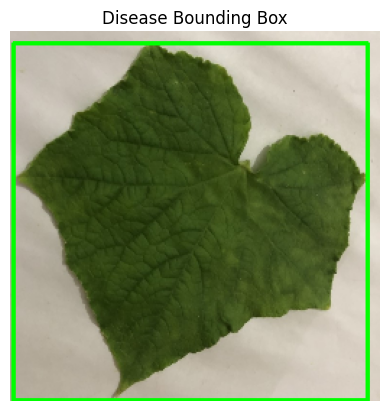

In [27]:
plt.imshow(result)
plt.title("Disease Bounding Box")
plt.axis("off")
plt.show()

In [29]:
disease_pixels = cv2.countNonZero(disease_mask)

print("Disease Pixels :", disease_pixels)

Disease Pixels : 10084


In [28]:
total_pixels = leaf_resize.shape[0] * leaf_resize.shape[1]

print("Total Pixels :", total_pixels)

Total Pixels : 65536


In [30]:
disease_percentage = (disease_pixels / total_pixels) * 100

print(f"Disease Percentage : {disease_percentage:.2f}%")

Disease Percentage : 15.39%


In [31]:
if disease_percentage < 5:
    severity = "Healthy"

elif disease_percentage < 20:
    severity = "Mild"

elif disease_percentage < 50:
    severity = "Moderate"

else:
    severity = "Severe"

print("Severity :", severity)

Severity : Mild


In [32]:
lower_green = np.array([25, 30, 30])
upper_green = np.array([90, 255, 255])

leaf_mask = cv2.inRange(leaf_hsv, lower_green, upper_green)

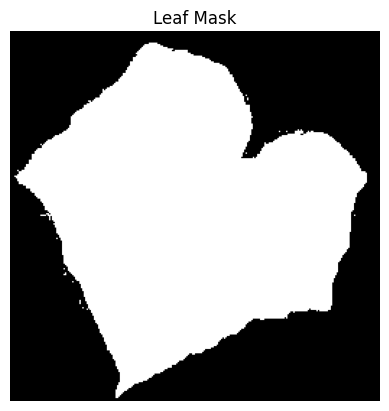

In [33]:
plt.imshow(leaf_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")
plt.show()

In [34]:
leaf_pixels = cv2.countNonZero(leaf_mask)

print("Leaf Pixels :", leaf_pixels)

Leaf Pixels : 33824


In [35]:
disease_percentage = (disease_pixels / leaf_pixels) * 100

print(f"Disease Percentage : {disease_percentage:.2f}%")

Disease Percentage : 29.81%


In [36]:
def load_image(image_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

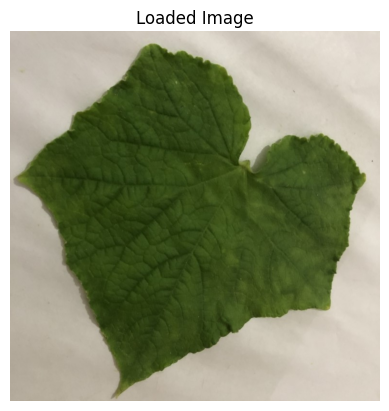

In [37]:
image = load_image(image_path)

plt.imshow(image)
plt.title("Loaded Image")
plt.axis("off")
plt.show()

In [38]:
image = load_image(image_path)

In [39]:
def create_leaf_mask(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower = np.array([25, 30, 30])
    upper = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    return mask

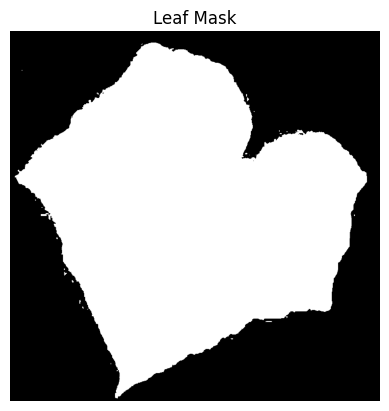

In [40]:
leaf_mask = create_leaf_mask(image)

plt.imshow(leaf_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")
plt.show()

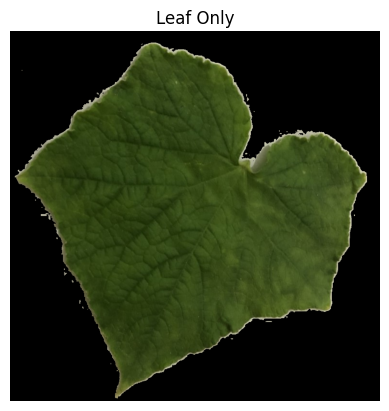

In [41]:
leaf_only = cv2.bitwise_and(image, image, mask=leaf_mask)

plt.imshow(leaf_only)
plt.title("Leaf Only")
plt.axis("off")
plt.show()

In [ ]:
def create_disease_mask(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower = np.array([10, 40, 40])
    upper = np.array([40, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    return mask

In [ ]:
disease_mask = create_disease_mask(leaf_only)

plt.imshow(disease_mask, cmap="gray")
plt.title("Disease Mask")
plt.axis("off")
plt.show()

In [ ]:
kernel = np.ones((5,5), np.uint8)

disease_mask = cv2.morphologyEx(
    disease_mask,
    cv2.MORPH_OPEN,
    kernel
)

plt.imshow(disease_mask, cmap="gray")
plt.title("Clean Disease Mask")
plt.axis("off")
plt.show()

In [ ]:
def highlight_disease(image, disease_mask):

    result = image.copy()

    contours, _ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:

        largest = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest)

        cv2.rectangle(result, (x, y), (x+w, y+h), (0,255,0), 2)

    return result

In [ ]:
result = highlight_disease(leaf_only, disease_mask)

plt.imshow(result)
plt.title("Disease Localization")
plt.axis("off")
plt.show()

In [ ]:
def highlight_disease(image, disease_mask):

    result = image.copy()

    overlay = image.copy()
    overlay[disease_mask > 0] = [255, 0, 0]

    result = cv2.addWeighted(overlay, 0.35, result, 0.65, 0)

    contours, _ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:

        largest = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest)

        cv2.rectangle(result, (x, y), (x+w, y+h), (0,255,0), 2)

    return result

In [ ]:
result = highlight_disease(leaf_only, disease_mask)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Final Disease Detection")
plt.axis("off")
plt.show()

In [ ]:
from skimage.feature import graycomatrix, graycoprops

In [ ]:
def extract_glcm_features(gray_image):

    glcm = graycomatrix(
        gray_image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return glcm

In [ ]:
glcm = extract_glcm_features(leaf_gray)

contrast = graycoprops(glcm, "contrast")[0,0]
energy = graycoprops(glcm, "energy")[0,0]
homogeneity = graycoprops(glcm, "homogeneity")[0,0]
correlation = graycoprops(glcm, "correlation")[0,0]

In [ ]:
print("Contrast    :", round(contrast,4))
print("Energy      :", round(energy,4))
print("Homogeneity :", round(homogeneity,4))
print("Correlation :", round(correlation,4))

In [ ]:
# ==========================================
# LESSON 17 - CREATE FEATURE DATASET
# ==========================================

features = []

# Supported image formats
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

for disease in disease_classes:

    folder = os.path.join(train_path, disease)

    print(f"\nProcessing : {disease}")

    for image_name in os.listdir(folder):

        # Skip non-image files
        if not image_name.lower().endswith(valid_extensions):
            continue

        image_path = os.path.join(folder, image_name)

        # Read image
        image = cv2.imread(image_path)

        # Skip corrupted images
        if image is None:
            print("Skipped :", image_name)
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image
        image = cv2.resize(image, (256, 256))

        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Extract GLCM
        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        # Calculate features
        contrast = graycoprops(glcm, "contrast")[0, 0]
        energy = graycoprops(glcm, "energy")[0, 0]
        homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
        correlation = graycoprops(glcm, "correlation")[0, 0]

        # Store features
        features.append([
            contrast,
            energy,
            homogeneity,
            correlation,
            disease
        ])

print("\nFeature Extraction Completed!")

# Create DataFrame
feature_data = pd.DataFrame(
    features,
    columns=[
        "Contrast",
        "Energy",
        "Homogeneity",
        "Correlation",
        "Disease"
    ]
)

# Save CSV
csv_path = os.path.join(project_path, "leaf_features.csv")
feature_data.to_csv(csv_path, index=False)

print("CSV Saved Successfully!")
print("Total Images Processed :", len(feature_data))

# Display first 5 rows
feature_data.head()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
feature_data = pd.read_csv(csv_path)

feature_data.head()

In [ ]:
X = feature_data.drop("Disease", axis=1)
y = feature_data["Disease"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("KNN Model Trained Successfully")

In [ ]:
prediction = knn.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print(f"Accuracy : {accuracy*100:.2f}%")

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X = feature_data.drop("Disease", axis=1)
y = feature_data["Disease"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print(f"Accuracy : {accuracy*100:.2f}%")

In [ ]:
accuracy_list = []

print("K Value  Accuracy")
print("-" * 20)

for k in range(1, 16, 2):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    accuracy_list.append(accuracy)

    print(f"{k}       {accuracy*100:.2f}%")

In [ ]:
best_k = range(1, 16, 2)[accuracy_list.index(max(accuracy_list))]

print("Best K :", best_k)
print("Best Accuracy :", f"{max(accuracy_list)*100:.2f}%")

In [ ]:
contrast = graycoprops(glcm, "contrast")[0,0]
energy = graycoprops(glcm, "energy")[0,0]
homogeneity = graycoprops(glcm, "homogeneity")[0,0]
correlation = graycoprops(glcm, "correlation")[0,0]
contrast = graycoprops(glcm, "contrast")[0,0]
energy = graycoprops(glcm, "energy")[0,0]
homogeneity = graycoprops(glcm, "homogeneity")[0,0]
correlation = graycoprops(glcm, "correlation")[0,0]
dissimilarity = graycoprops(glcm, "dissimilarity")[0,0]
asm = graycoprops(glcm, "ASM")[0,0]

In [ ]:
features.append([
    contrast,
    energy,
    homogeneity,
    correlation,
    disease
])
features.append([
    contrast,
    energy,
    homogeneity,
    correlation,
    dissimilarity,
    asm,
    disease
])

In [ ]:
columns=[
    "Contrast",
    "Energy",
    "Homogeneity",
    "Correlation",
    "Disease"
]
columns=[
    "Contrast",
    "Energy",
    "Homogeneity",
    "Correlation",
    "Dissimilarity",
    "ASM",
    "Disease"
]

In [ ]:
csv_path = os.path.join(project_path, "leaf_features.csv")

feature_data.to_csv(csv_path, index=False)

print("New Feature Dataset Saved")

In [ ]:
feature_data.head()

In [ ]:
feature_data = pd.read_csv(csv_path)

feature_data.head()

In [ ]:
X = feature_data.drop("Disease", axis=1)

y = feature_data["Disease"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

best_accuracy = 0
best_k = 0

print("K Value\tAccuracy")
print("-" * 25)

for k in range(1, 16, 2):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    prediction = knn.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print(f"{k}\t{accuracy*100:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print("\n========================")
print("Best K :", best_k)
print(f"Best Accuracy : {best_accuracy*100:.2f}%")

In [ ]:
import joblib

In [ ]:
best_k = 7
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train, y_train)

print("Final KNN Model Trained Successfully")

In [ ]:
model_path = os.path.join(project_path, "knn_model.pkl")

joblib.dump(final_knn, model_path)

print("KNN Model Saved")

In [ ]:
scaler_path = os.path.join(project_path, "scaler.pkl")

joblib.dump(scaler, scaler_path)

print("Scaler Saved")

In [ ]:
import joblib

model_path = os.path.join(project_path, "knn_model.pkl")
scaler_path = os.path.join(project_path, "scaler.pkl")

knn = joblib.load(model_path)
scaler = joblib.load(scaler_path)

print("Model Loaded Successfully")

In [ ]:
test_folder = os.path.join(dataset_path, "test", "Healthy_leaves")

image_name = os.listdir(test_folder)[0]

image_path = os.path.join(test_folder, image_name)

print(image_path)

In [ ]:
image = load_image(image_path)

plt.imshow(image)
plt.title("Test Image")
plt.axis("off")
plt.show()

In [ ]:
image = cv2.resize(image, (256,256))

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

glcm = extract_glcm_features(gray)

features = [
    graycoprops(glcm,"contrast")[0,0],
    graycoprops(glcm,"energy")[0,0],
    graycoprops(glcm,"homogeneity")[0,0],
    graycoprops(glcm,"correlation")[0,0],
    graycoprops(glcm,"dissimilarity")[0,0],
    graycoprops(glcm,"ASM")[0,0]
]

In [ ]:
features = [
    graycoprops(glcm, "contrast")[0,0],
    graycoprops(glcm, "energy")[0,0],
    graycoprops(glcm, "homogeneity")[0,0],
    graycoprops(glcm, "correlation")[0,0]
]

In [ ]:
features = scaler.transform([features])

In [ ]:
prediction = knn.predict(features)

print("Predicted Disease :", prediction[0])

In [ ]:
def predict_leaf_disease(image_path):

    # Load Image
    image = load_image(image_path)

    # Resize Image
    image = cv2.resize(image, (256, 256))

    # Convert to Gray
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Extract GLCM
    glcm = extract_glcm_features(gray)

    # Create Feature Vector
    features = [[
        graycoprops(glcm, "contrast")[0,0],
        graycoprops(glcm, "energy")[0,0],
        graycoprops(glcm, "homogeneity")[0,0],
        graycoprops(glcm, "correlation")[0,0]
    ]]

    # Scale Features
    features = scaler.transform(features)

    # Predict Disease
    prediction = knn.predict(features)[0]

    # Display Image
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.title(prediction)
    plt.axis("off")
    plt.show()

    # Print Result
    print("Predicted Disease :", prediction)

In [ ]:
test_image = os.path.join(
    dataset_path,
    "test",
    "Healthy_leaves",
    os.listdir(os.path.join(dataset_path, "test", "Healthy_leaves"))[0]
)

predict_leaf_disease(test_image)

In [ ]:
def find_severity(percentage):

    if percentage < 5:
        return "Healthy"

    elif percentage < 20:
        return "Mild"

    elif percentage < 50:
        return "Moderate"

    else:
        return "Severe"

In [ ]:
severity = find_severity(disease_percentage)

print("\n========== RESULT ==========")
print("Disease :", prediction)
print(f"Disease Area : {disease_percentage:.2f}%")
print("Severity :", severity)
print("============================")

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(result)

plt.title(f"{prediction} ({severity})")

plt.axis("off")

plt.show()

In [ ]:
def predict_leaf_disease(image_path):

    image = load_image(image_path)

    ...

In [ ]:
# ==========================================
# Disease Recommendation
# ==========================================

recommendation = {

    "Healthy_leaves": [
        "Leaf is Healthy",
        "No Treatment Required"
    ],

    "Downy_mildew": [
        "Apply Mancozeb Fungicide",
        "Remove Infected Leaves"
    ],

    "Powdery_mildew": [
        "Apply Sulfur Fungicide",
        "Improve Air Circulation"
    ]
}

In [ ]:
print("Predicted Disease :", prediction)
